# College Scorecard API in Python

by Michael T. Moen

The College Scorecard API is an online tool hosted by the U.S. Department of Education that contains data concerning higher education institutions.

Please see the following resources for more information on API usage:

- Documentation
    - <a href="https://collegescorecard.ed.gov/data/api-documentation/" target="_blank">College Scorecard API Documentation</a>
- Data Reuse
    - <a href="https://www.ed.gov/about/ed-overview/required-notices/website-policies/copyright-status-notice-us-department-of-education" target="_blank">College Scorecard Copyright Status</a>
    - <a href="https://data.gov/privacy-policy/" target="_blank">Data\.gov Privacy Policy</a>

**_NOTE:_** Please see access details and rate limit requests for this API in the official documentation.

*These recipe examples were tested on February 3, 2026.*

## Setup

### Import Libraries

The following external libraries need to be installed into your environment to run the code examples in this tutorial:

- <a href="https://github.com/ipython/ipykernel" target="_blank">ipykernel</a>
- <a href="https://github.com/matplotlib/matplotlib" target="_blank">matplotlib</a>
- <a href="https://github.com/numpy/numpy" target="_blank">numpy</a>
- <a href="https://github.com/pandas-dev/pandas" target="_blank">pandas</a>
- <a href="https://github.com/theskumar/python-dotenv" target="_blank">python-dotenv</a>
- <a href="https://github.com/psf/requests" target="_blank">requests</a>

We import the libraries used in this tutorial below:

In [1]:
import requests
from pprint import pprint
from time import sleep
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

### Import API Key

An API key is required to access the College Scorecard API. You can sign up for one at the <a href="https://collegescorecard.ed.gov/data/api-documentation#api-access-and-authentication" target="_blank">College Scorecard Website</a>.

We keep our API key in a `.env` file and use the `dotenv` library to access it. If you would like to use this method, create a `.env` file and add the following line to it:

```text
COLLEGE_SCORECARD_API_KEY=PUT_YOUR_API_KEY_HERE
```

In [2]:
load_dotenv()
try:
    API_KEY = os.environ["COLLEGE_SCORECARD_API_KEY"]
except KeyError:
    print("API key not found. Please set 'COLLEGE_SCORECARD_API_KEY' in your .env file.")

## 1. Get Names of All Institutions

To start, we'll use a basic query to find the names of all educational institutions recognized by the College Scorecard API.

All of the data for the API can be found using the `v1/schools` endpoint.

Fields in the College Scorecard API are accessed with a `<time>.<category>.<name>` sequence:
- `<time>` indicates the year of the data to be accessed. To access the most recent data, use `latest`.
- `<category>` and `<name>` can be found in the Data Dictionary file that can be downloaded from the API's documentation. The `<category>` of a field is given by the `dev-category` column in the `Institution_Data_Dictionary` section, and the `<name>` is given by the `developer-friendly name` column.

In [3]:
BASE_URL = 'http://api.data.gov/ed/collegescorecard/v1/schools'
params = {
    'fields': 'school.name',
    'api_key': API_KEY
}

names = requests.get(BASE_URL, params=params).json()

# Display resulting metadata
names['metadata']

{'page': 0, 'total': 6429, 'per_page': 20}

The `total` value indicates the total number results returned in this query. These results are paginated, so each query will return only the number indicated by `page_size`, which has a default value of 20 and a maximum value of 100. The page number is indicated by `page`, which by default is set to 0.

We can use a loop to create an API request for each page:

In [4]:
field = 'school.name'
sort_key = 'school.name'
page_size = 100

# Calculate the number of loops needed to page through every result
total_pages = (names['metadata']['total'] // page_size) + 1

institution_names = []

# Loop through each page of the dataset, sending a request for each page
for page_number in range(total_pages):

    params = {
        'fields': field,
        'page': page_number,
        'per_page': page_size,
        'sort': sort_key,
        'api_key': API_KEY
    }
    name_data = requests.get(BASE_URL, params=params).json()['results']

    for university in name_data:
        institution_names.append(university['school.name'])

    # Wait 1 second between API calls to be nicer on the host servers
    sleep(1)

# Display number of institution names found
len(institution_names)

6429

In [5]:
# Print first 10 institution names
institution_names[:10]

['A Better U Beauty Barber Academy',
 'A T Still University of Health Sciences',
 'Aaniiih Nakoda College',
 'ABC Adult School',
 'ABC Adult School - Cabrillo Lane',
 'ABC Beauty Academy',
 'ABCO Technology',
 'Abcott Institute',
 'Abilene Christian University',
 'Abilene Christian University-Undergraduate Online']

## 2. Get Names of All Universities

College Scorecard API requests can also take conditions to only select certain institutions.

In this example, we limit the results to only include institutions that award graduate degrees. In order to do this, we set the `degrees_awarded.highest` parameter to `4` to indicate that the highest degree awarded by an institution is a graduate degree. This information is within the `Institution_Data_Dictionary` section of the College Scorecard data disctionary.

In [6]:
field = 'school.name'
sort_key = 'school.name'
page_size = 100

# Calculate the number of loops needed to page through every result
params = {
    'fields': field,
    'latest.school.degrees_awarded.highest': 4,
    'api_key': API_KEY
}
name_metadata = requests.get(BASE_URL, params=params).json()['metadata']
total_pages = (name_metadata['total'] // page_size) + 1

university_names = []

for page_number in range(total_pages):

    params = {
        'fields': field,
        'latest.school.degrees_awarded.highest': 4,
        'sort': sort_key,
        'page': page_number,
        'per_page': page_size,
        'api_key': API_KEY
    }
    name_data = requests.get(BASE_URL, params=params).json()['results']

    for university in name_data:
        university_names.append(university['school.name'])

    # Wait 1 second between API calls to be nicer on the host servers
    sleep(1)

# Display the number of university names found
len(university_names)

1985

In [7]:
# Print first 10 university names
university_names[:10]

['A T Still University of Health Sciences',
 'Abilene Christian University',
 'Abraham Lincoln University',
 'Academy for Five Element Acupuncture',
 'Academy for Jewish Religion',
 'Academy for Jewish Religion California',
 'Academy of Art University',
 'Academy of Chinese Culture and Health Sciences',
 'Academy of Vocal Arts',
 'Acupuncture and Integrative Medicine College-Berkeley']

## 3. Find Number of Universities by State

The `school.state_fips` data element contains a number that corresponds to each state. This mapping is given below:

In [8]:
states = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California', 8: 'Colorado',
    9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia', 12: 'Florida', 13: 'Georgia',
    15:	'Hawaii', 16: 'Idaho', 17: 'Illinois', 18: 'Indiana', 19: 'Iowa', 20: 'Kansas',
    21:	'Kentucky', 22: 'Louisiana', 23: 'Maine', 24: 'Maryland', 25: 'Massachusetts',
    26:	'Michigan', 27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31:	'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey', 35: 'New Mexico',
    36:	'New York', 37: 'North Carolina', 38: 'North Dakota', 39: 'Ohio', 40: 'Oklahoma',
    41:	'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island', 45: 'South Carolina',
    46:	'South Dakota', 47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont',
    51: 'Virginia', 53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming',
    60: 'American Samoa', 64: 'Federated States of Micronesia', 66: 'Guam',
    69: 'Northern Mariana Islands', 70: 'Palau', 72: 'Puerto Rico', 78: 'Virgin Islands'
}

Using this mapping, we can find the number of universities in each state:

In [9]:
field = 'latest.school.state_fips'
page_size = 100

# Calculate the number of loops needed to page through every result
params = {
    'latest.school.degrees_awarded.highest': 4,
    'fields': field,
    'api_key': API_KEY
}
name_metadata = requests.get(BASE_URL, params=params).json()['metadata']
total_pages = (name_metadata['total'] // page_size) + 1

state_freq = {}
for page_number in range(total_pages):

    params = {
        'latest.school.degrees_awarded.highest': 4,
        'fields': field,
        'page': page_number,
        'per_page': page_size,
        'api_key': API_KEY
    }
    state_data = requests.get(BASE_URL, params=params).json()['results']

    for university in state_data:
        state = states[university['latest.school.state_fips']]
        state_freq[state] = state_freq.get(state, 0) + 1
    
    # Wait 1 second between API calls to be nicer on the host servers
    sleep(1)

Now, we can sort and display the results:

In [10]:
# Sort states by number of universities in descending order
sorted_states = sorted(state_freq.items(), key=lambda x: x[1], reverse=True)

# Print the top 20 states/territories with the most universities
for state_name, num_universities in sorted_states[:20]:
    print(f'{state_name:<15} {num_universities}')

California      201
New York        154
Pennsylvania    112
Texas           103
Illinois        79
Florida         75
Massachusetts   73
Ohio            69
North Carolina  57
Missouri        55
Virginia        53
Indiana         50
Georgia         49
Tennessee       47
Puerto Rico     47
Michigan        46
Minnesota       39
New Jersey      38
Wisconsin       37
South Carolina  35


## 4. Retrieving Multiple Data Points in a Single Query

The following example uses multiple conditions and multiple fields. The conditions in the query are separated by `&` while the fields are separated by `,`.

In [11]:
# Use .join to add ',' between the elements in the list of fields
fields = ','.join([
    'school.name',
    'latest.admissions.admission_rate.overall',
    'latest.student.size',
    'latest.cost.tuition.out_of_state',
    'latest.cost.tuition.in_state',
    'latest.student.demographics.median_hh_income',
    'latest.school.endowment.begin'
])
sort_key = 'school.name'
page_size = 100

# Calculate the number of loops needed to page through every result
params = {
    'fields': fields,
    'latest.school.degrees_awarded.highest': 4,
    'latest.student.size__range': '1000..', # Schools with 1000 or more students
    'api_key': API_KEY
}
name_metadata = requests.get(BASE_URL, params=params).json()['metadata']
total_pages = (name_metadata['total'] // page_size) + 1

rows = []

for page_number in range(total_pages):

    params = {
        'fields': fields,
        'latest.school.degrees_awarded.highest': 4,
        'latest.student.size__range': '1000..',
        'page': page_number,
        'per_page': page_size,
        'sort': sort_key,
        'api_key': API_KEY
    }
    data = requests.get(BASE_URL, params=params).json()['results']

    for university in data:
        rows.append([
            university['school.name'],
            university['latest.admissions.admission_rate.overall'],
            university['latest.student.size'],
            university['latest.cost.tuition.out_of_state'],
            university['latest.cost.tuition.in_state'],
            university['latest.student.demographics.median_hh_income'],
            university['latest.school.endowment.begin']
        ])
    
    # Wait 1 second between API calls to be nicer on the host servers
    sleep(1)

columns = ['Name', 'Admission Rate', 'Size', 'Tuition Out of State', 'Tuition In State',
           'Median Household Income', 'Endowment']
df = pd.DataFrame(rows, columns=columns)

# Display the dataframe
df

,Name,Admission Rate,Size,Tuition Out of State,Tuition In State,Median Household Income,Endowment
0,Abilene Christian University,0.6388,3129,42380.0,42380.0,67136.0,6.055984e+08
1,Academy of Art University,NaN,4131,28024.0,28024.0,74015.0,NaN
2,Adams State University,NaN,1239,21848.0,9776.0,50726.0,6.267400e+04
3,Adelphi University,0.7751,5077,47290.0,47290.0,80864.0,2.123457e+08
4,Adrian College,0.6837,1635,40556.0,40556.0,66915.0,4.106072e+07
...,...,...,...,...,...,...,...
1145,Xavier University of Louisiana,0.7448,2534,27868.0,27868.0,55657.0,1.627134e+08
1146,Yale University,0.0450,6811,64700.0,64700.0,75345.0,4.138326e+10
1147,Yeshiva University,0.6375,2942,49900.0,49900.0,78671.0,5.183480e+08
1148,York College of Pennsylvania,0.9420,3187,24606.0,24606.0,73378.0,1.709745e+08


We can query the resulting dataframe to find the data for specific universities:

In [12]:
df[df['Name'] == 'The University of Alabama']

,Name,Admission Rate,Size,Tuition Out of State,Tuition In State,Median Household Income,Endowment
829,The University of Alabama,0.7582,32323,33200.0,11900.0,57928.0,1.144633e+09


We can also query the dataframe to find the data for universities that satisfy certain conditions:

In [13]:
df[df['Admission Rate'] < 0.1]

,Name,Admission Rate,Size,Tuition Out of State,Tuition In State,Median Household Income,Endowment
95,Brown University,0.0523,7273,68230.0,68230.0,79027.0,6.141243e+09
104,California Institute of Technology,0.0314,1023,63255.0,63255.0,81448.0,3.390504e+09
183,Columbia University in the City of New York,0.0423,8899,69045.0,69045.0,76971.0,1.327985e+10
196,Cornell University,0.0816,15935,66014.0,66014.0,80346.0,9.349247e+09
215,Dartmouth College,0.0623,4367,65739.0,65739.0,79834.0,8.065743e+09
235,Duke University,0.0678,6417,65805.0,65805.0,78468.0,1.211626e+10
344,Harvard University,0.0345,7755,59076.0,59076.0,76879.0,5.087768e+10
392,Johns Hopkins University,0.0756,5617,63340.0,63340.0,81539.0,8.244472e+09
468,Massachusetts Institute of Technology,0.0474,4571,60156.0,60156.0,77426.0,2.460081e+10
549,New York University,0.0941,29430,60438.0,60438.0,82106.0,5.235504e+09


In [14]:
df[df['Endowment'] > 1.0e+10]

,Name,Admission Rate,Size,Tuition Out of State,Tuition In State,Median Household Income,Endowment
183,Columbia University in the City of New York,0.0423,8899,69045.0,69045.0,76971.0,1.327985e+10
235,Duke University,0.0678,6417,65805.0,65805.0,78468.0,1.211626e+10
265,Emory University,0.1110,7275,60774.0,60774.0,80509.0,1.115540e+10
344,Harvard University,0.0345,7755,59076.0,59076.0,76879.0,5.087768e+10
468,Massachusetts Institute of Technology,0.0474,4571,60156.0,60156.0,77426.0,2.460081e+10
578,Northwestern University,0.0715,8960,65997.0,65997.0,81811.0,1.087985e+10
630,Princeton University,0.0450,5579,59710.0,59710.0,81428.0,3.512622e+10
761,Stanford University,0.0391,7841,62484.0,62484.0,80275.0,3.633879e+10
809,Texas A&M University-College Station,0.6325,59099,40328.0,13099.0,67194.0,1.721950e+10
955,University of Michigan-Ann Arbor,0.1794,33488,58072.0,17228.0,77145.0,1.710443e+10


## 5. Retrieving All Data for an Institution

The College Scorecard API can also be used to retrieve all of the data for a particular institution. The example below finds all data for The University of Alabama:

In [15]:
params = {
    'school.name': 'The University of Alabama',
    'api_key': API_KEY
}
api_data = requests.get(BASE_URL, params=params).json()

# Print structure of the result
pprint(api_data["results"][0], depth=1)

{'fed_sch_cd': '001051',
 'id': 100751,
 'latest': {...},
 'location': {...},
 'ope6_id': '001051',
 'ope8_id': '00105100',
 'school': {...}}


Finally, we'll look at the breakdown of size of each program at the University of Alabama:

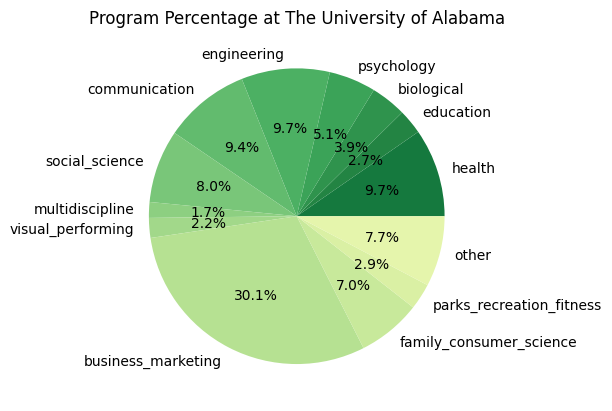

In [16]:
program_percentage_data = api_data['results'][0]['latest']['academics']['program_percentage']
programs = list(program_percentage_data.keys())
percentages = list(program_percentage_data.values())

smallest_percent_allowed = 0.015 # Any sector under this threshold will be added to "other"
small_slices = 0 # The number of slices below the threshold above

# Count the number of small slices
small_slices = sum(1 for i in percentages if i < smallest_percent_allowed)

# If there is more than one slice smaller than the threshold, combine those slices into "other"
if small_slices > 1:
    other_percentage = 0
    i = len(program_percentage_data) - 1
    while i >= 0:
        if percentages[i] < smallest_percent_allowed:
            other_percentage += percentages[i]
            programs.pop(i)
            percentages.pop(i)
        i -= 1
    percentages.append(other_percentage)
    programs.append("other")

# Configure color of pie chart
cmap = plt.get_cmap('YlGn_r')
colors = cmap(np.linspace(0.2, 0.8, len(percentages)))

fig, ax = plt.subplots()
plt.pie(percentages, labels=programs, autopct='%1.1f%%', colors=colors)
plt.title("Program Percentage at The University of Alabama")

plt.show()

In [17]:
# Sort the dictionary by keys
sorted_program_percentage_data = dict(
    sorted(program_percentage_data.items(), key=lambda x: x[1], reverse=True)
)

# Print the sorted dictionary
for key, value in sorted_program_percentage_data.items():
    print(f'{key}: {value}')

business_marketing: 0.3011
health: 0.0966
engineering: 0.0966
communication: 0.0942
social_science: 0.0799
family_consumer_science: 0.0696
psychology: 0.0513
biological: 0.0389
parks_recreation_fitness: 0.0286
education: 0.0272
visual_performing: 0.0217
multidiscipline: 0.0172
computer: 0.0144
history: 0.0117
public_administration_social_service: 0.0109
physical_science: 0.0106
english: 0.0097
mathematics: 0.0089
language: 0.0045
resources: 0.0038
philosophy_religious: 0.0018
ethnic_cultural_gender: 0.0009
legal: 0
library: 0
military: 0
humanities: 0
agriculture: 0
architecture: 0
construction: 0
transportation: 0
personal_culinary: 0
science_technology: 0
precision_production: 0
engineering_technology: 0
security_law_enforcement: 0
communications_technology: 0
mechanic_repair_technology: 0
theology_religious_vocation: 0
